# 🏏 IPL Data Scientist Hiring

<div style="background-color: #1e3a8a; color: white; padding: 20px; border-radius: 10px;">
<h2>Position: Senior Data Scientist - IPL Analytics Team</h2>

<p><b>Dataset:</b> Indian IPL Dataset 2008-2024</p>
<p><b>Submission:</b> Jupyter Notebook with code, visualizations, and insights</p>
</div>

## 📊 Background

The Indian Premier League (IPL) is seeking a talented Data Scientist to join our analytics team. Your role will involve analyzing match data, player performance, fan sentiment, and providing strategic insights to team management.

## 📁 Dataset Information

**Key Columns:**
- `id:` A unique identifier assigned to each IPL match.
- `season:` The year in which the IPL season took place.
- `city`: The city where the match was played.
- `date`: The date on which the match was held.
- `match_type`: Type of the match (e.g., League, Playoff, Final).
- `player_of_match`: The player who was awarded “Player of the Match” for their performance.
- `venue`: The stadium or ground where the match was played.
- `team1`: The first team listed in the fixture.
- `team2`: The second team listed in the fixture.
- `toss_winner`: The team that won the toss before the match began.
- `toss_decision`: The decision made by the toss-winning team—either to bat or to field first.
- `winner`: The team that won the match.
- `result`: The method of victory—either by runs, wickets, or other (e.g., tie, no result).
- `result_margin`: The margin by which the match was won (e.g., number of runs or wickets).
- `target_runs`: The number of runs set as a target for the chasing team.
- `target_overs`: The number of overs available to chase the target.
- `super_over`: Indicates whether the match was decided by a super over (‘Y’ for Yes, ‘N’ for No).
- `method`: The method used to decide the match result if it was interrupted (e.g., Duckworth–Lewis method).
- `umpire1`: Name of the first on-field umpire officiating the match.
- `umpire2`: Name of the second on-field umpire officiating the match.
---

# **FEATURES mentioned in questions are high level example. You can create more features to make your model robust **

## 📝 Question 1: Data Preprocessing & Feature Engineering

### Task:
1. Load the IPL dataset and perform comprehensive EDA
2. Handle missing values appropriately with justification
3. Create these new features:(**These are examples you can create more along with this )**
   - `home_advantage`: Boolean indicating if team1 is playing in their home city(optional can be done with assumption)
   - venue_matches_team1_prior / venue_matches_team2_prior: number of matches the team has played at this same venue before the current match date
   - `match_importance`: Categorical (league/playoff/final) based on date and season
   - `toss_advantage`: Whether toss winner won the match
   - `season_phase`: Early/Mid/Late season

### Deliverables:
- Clean dataset with no missing values
- Visualization showing distribution of matches across venues
- Statistical summary of win percentages for toss winners

```python
# Your code here
```

In [1]:
# Clustering Imports
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load IPL dataset
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("IPL_2008-2024.csv")

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Saving IPL_2008-2024.csv to IPL_2008-2024.csv
Dataset Shape: (1095, 20)

Columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
# BASIC DATASET INFORMATION

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data_Type"))

print("\nDataset Information:")
df.info()

Number of rows: 1095
Number of columns: 20

Column Names:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Data Types:


,Data_Type
id,int64
season,int64
city,object
date,object
match_type,object
player_of_match,object
venue,object
team1,object
team2,object
toss_winner,object



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   int64  
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   objec

In [4]:
# Missing Values
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary
    .sort_values("Missing_Count", ascending=False)
)

display(missing_summary)

,Missing_Count,Missing_Percentage
method,1074,98.08
city,51,4.66
result_margin,19,1.74
player_of_match,5,0.46
winner,5,0.46
target_runs,3,0.27
target_overs,3,0.27
id,0,0.00
date,0,0.00
season,0,0.00


In [5]:
# DUPLICATE CHECK
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate match IDs:", df["id"].duplicated().sum())

Duplicate rows: 0
Duplicate match IDs: 0


,season,matches
0,2008,58
1,2009,57
2,2010,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


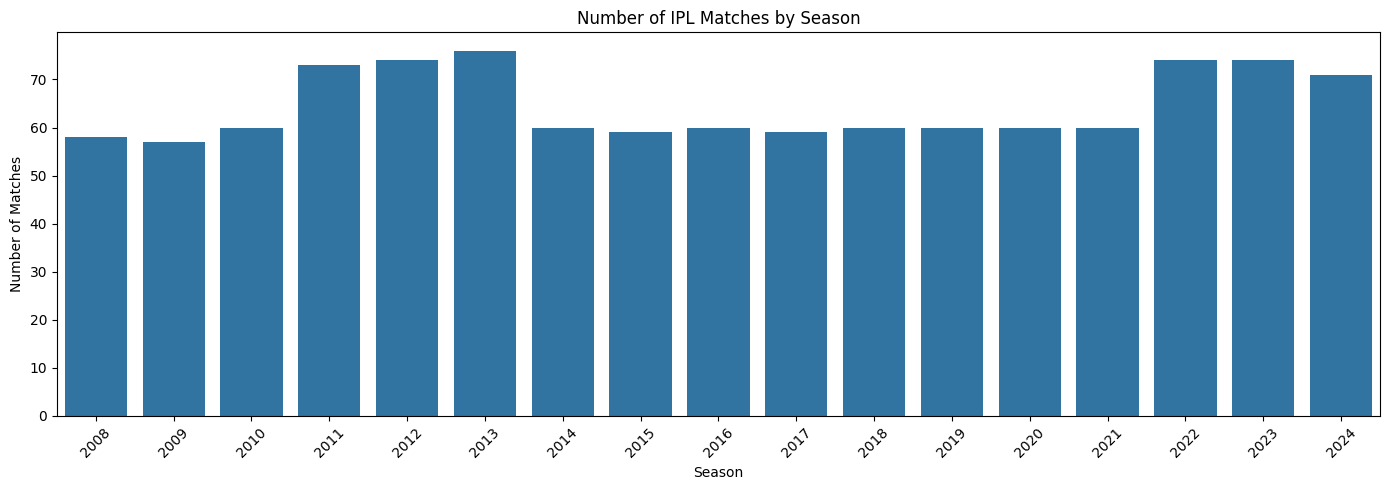

In [6]:
# Season Distribution - MATCHES BY SEASON
season_counts = (
    df.groupby("season")
      .size()
      .reset_index(name="matches")
)

display(season_counts)

plt.figure(figsize=(14, 5))

sns.barplot(
    data=season_counts,
    x="season",
    y="matches"
)

plt.title("Number of IPL Matches by Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# Data Type Convertions
# Convert date
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# Numeric columns
numeric_columns = [
    "season",
    "result_margin",
    "target_runs",
    "target_overs"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# String/categorical columns
categorical_columns = [
    "city",
    "match_type",
    "player_of_match",
    "venue",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "winner",
    "result",
    "super_over",
    "method",
    "umpire1",
    "umpire2"
]

for col in categorical_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
    )

In [8]:
# Missing Value Treatment
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
})

display(
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
)

,missing_count,missing_percentage
city,51,4.66
player_of_match,5,0.46
winner,5,0.46
result_margin,19,1.74
target_runs,3,0.27
target_overs,3,0.27
method,1074,98.08


In [9]:
# HANDLE MISSING VALUES

# Categorical columns
categorical_fill = [
    "city",
    "player_of_match",
    "result",
    "method",
    "super_over",
    "umpire1",
    "umpire2"
]

for col in categorical_fill:
    df[col] = df[col].fillna("Not Available")


# Numeric columns where missing means
# the metric was not applicable
df["result_margin"] = df["result_margin"].fillna(0)
df["target_runs"] = df["target_runs"].fillna(0)
df["target_overs"] = df["target_overs"].fillna(0)

# Preserve the fact that these matches had no recorded winner
df["winner_available"] = df["winner"].notna()

df["winner"] = df["winner"].fillna("No Winner")

In [10]:
# Feature Engineering
# TOSS ADVANTAGE
df["toss_advantage"] = np.where(
    (df["toss_winner"] == df["winner"]) &
    (df["winner"] != "No Winner"),
    True,
    False
)
df["toss_advantage"].value_counts()


,count
toss_advantage,
True,554
False,541


This represents:
True → Toss winner subsequently won the match
False → Toss winner did not win the match

In [11]:
# SEASON PHASE

df = df.sort_values(
    ["season", "date"]
).reset_index(drop=True)

df["season_match_number"] = (
    df.groupby("season")
      .cumcount() + 1
)

df["season_total_matches"] = (
    df.groupby("season")["id"]
      .transform("count")
)

df["season_progress"] = (
    df["season_match_number"] /
    df["season_total_matches"]
)

df["season_phase"] = pd.cut(
    df["season_progress"],
    bins=[0, 1/3, 2/3, 1],
    labels=["Early", "Mid", "Late"],
    include_lowest=True
)

display(
    df[
        [
            "season",
            "date",
            "season_match_number",
            "season_progress",
            "season_phase"
        ]
    ].head(20)
)

,season,date,season_match_number,season_progress,season_phase
0,2008,2008-04-18,1,0.017241,Early
1,2008,2008-04-19,2,0.034483,Early
2,2008,2008-04-19,3,0.051724,Early
3,2008,2008-04-20,4,0.068966,Early
4,2008,2008-04-20,5,0.086207,Early
5,2008,2008-04-21,6,0.103448,Early
6,2008,2008-04-22,7,0.120690,Early
7,2008,2008-04-23,8,0.137931,Early
8,2008,2008-04-24,9,0.155172,Early
9,2008,2008-04-25,10,0.172414,Early


In [12]:
# venue_matches_team1_prior - PRIOR VENUE EXPERIENCE

df = df.sort_values("date").reset_index(drop=True)

team_venue_history = {}

team1_prior = []
team2_prior = []

for _, row in df.iterrows():

    venue = row["venue"]
    team1 = row["team1"]
    team2 = row["team2"]

    key1 = (team1, venue)
    key2 = (team2, venue)

    team1_prior.append(
        team_venue_history.get(key1, 0)
    )

    team2_prior.append(
        team_venue_history.get(key2, 0)
    )

    # Update history AFTER calculating prior experience
    team_venue_history[key1] = (
        team_venue_history.get(key1, 0) + 1
    )

    team_venue_history[key2] = (
        team_venue_history.get(key2, 0) + 1
    )

df["venue_matches_team1_prior"] = team1_prior
df["venue_matches_team2_prior"] = team2_prior

# Check Result


In [13]:
# HOME ADVANTAGE
home_city_mapping = {
    "Mumbai Indians": "Mumbai",
    "Chennai Super Kings": "Chennai",
    "Royal Challengers Bengaluru": "Bengaluru",
    "Royal Challengers Bangalore": "Bangalore",
    "Kolkata Knight Riders": "Kolkata",
    "Delhi Capitals": "Delhi",
    "Delhi Daredevils": "Delhi",
    "Punjab Kings": "Mohali",
    "Kings XI Punjab": "Mohali",
    "Rajasthan Royals": "Jaipur",
    "Sunrisers Hyderabad": "Hyderabad",
    "Deccan Chargers": "Hyderabad",
    "Gujarat Titans": "Ahmedabad",
    "Lucknow Super Giants": "Lucknow",
    "Rising Pune Supergiant": "Pune",
    "Rising Pune Supergiants": "Pune",
    "Pune Warriors": "Pune"
}

df["team1_home_city"] = df["team1"].map(
    home_city_mapping
)

df["team2_home_city"] = df["team2"].map(
    home_city_mapping
)

df["home_advantage"] = (
    (df["city"] == df["team1_home_city"]) |
    (df["city"] == df["team2_home_city"])
)
# For the feature specifically requested as "team1 is playing in their home city"
df["team1_home_advantage"] = (
    df["city"] == df["team1_home_city"]
)

In [14]:
# Match Importance
df["match_type"].value_counts(dropna=False)

def classify_match_importance(row):

    match_type = str(row["match_type"]).lower()

    if "final" in match_type:
        return "Final"

    elif any(
        x in match_type
        for x in ["qualifier", "eliminator", "playoff"]
    ):
        return "Playoff"

    else:
        return "League"


df["match_importance"] = df.apply(
    classify_match_importance,
    axis=1
)

# Check
display(
    df["match_importance"]
    .value_counts()
    .to_frame("matches")
)

,matches
match_importance,
League,1030
Playoff,39
Final,26


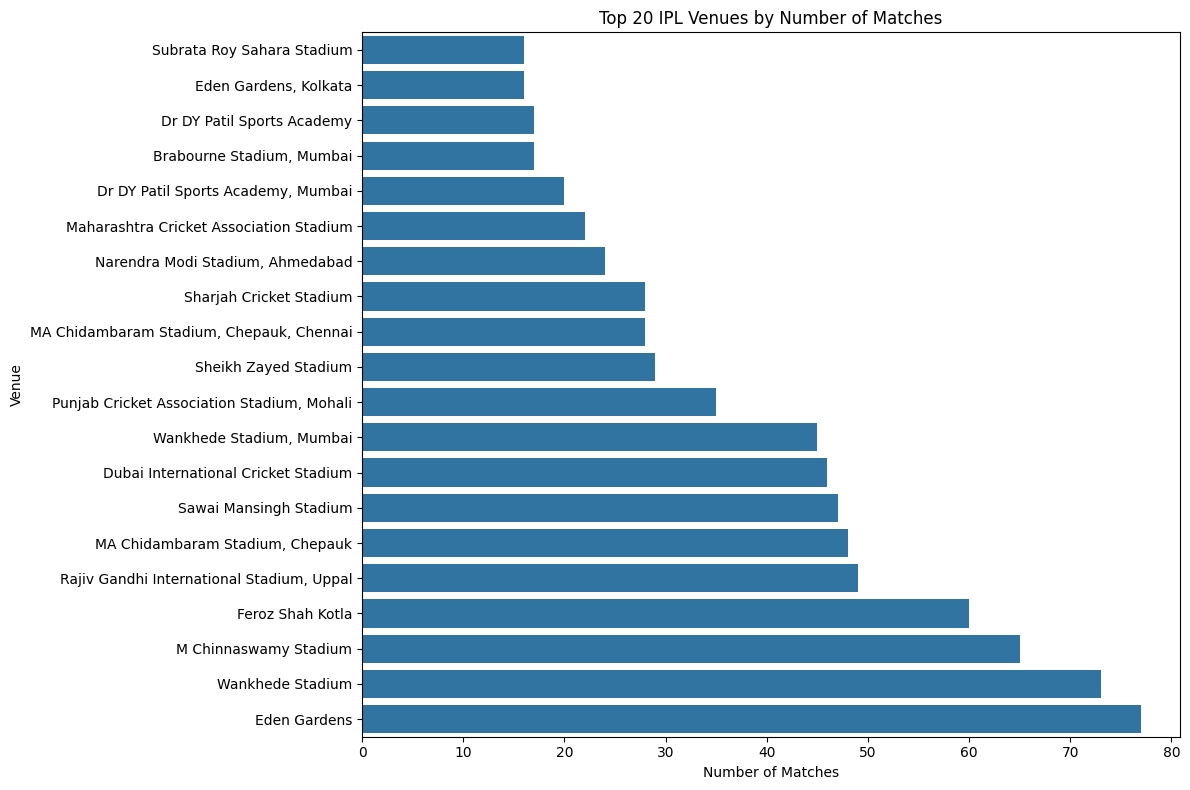

In [15]:
# Visualizations - MATCH DISTRIBUTION BY VENUE

top_venues = (
    df["venue"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_venues.values,
    y=top_venues.index
)

plt.title("Top 20 IPL Venues by Number of Matches")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

plt.tight_layout()
plt.show()

In [16]:
# Required Statistical Summary – Toss Winner
# TOSS WINNER STATISTICS

valid_toss_matches = df[
    (df["toss_winner"] != "No Winner") &
    (df["winner"] != "No Winner")
].copy()

valid_toss_matches["toss_winner_won_match"] = (
    valid_toss_matches["toss_winner"] ==
    valid_toss_matches["winner"]
)

toss_summary = pd.DataFrame({
    "Total Matches": [
        len(valid_toss_matches)
    ],

    "Toss Winner Won": [
        valid_toss_matches[
            "toss_winner_won_match"
        ].sum()
    ],

    "Toss Winner Lost": [
        (~valid_toss_matches[
            "toss_winner_won_match"
        ]).sum()
    ],

    "Toss Winner Win %": [
        valid_toss_matches[
            "toss_winner_won_match"
        ].mean() * 100
    ]
})

toss_summary["Toss Winner Win %"] = (
    toss_summary["Toss Winner Win %"].round(2)
)

display(toss_summary)

,Total Matches,Toss Winner Won,Toss Winner Lost,Toss Winner Win %
0,1090,554,536,50.83


,season,matches,toss_winner_wins,toss_winner_win_pct
0,2008,58,28,48.28
1,2009,57,33,57.89
2,2010,60,31,51.67
3,2011,72,38,52.78
4,2012,74,33,44.59
5,2013,76,36,47.37
6,2014,60,30,50.0
7,2015,57,28,49.12
8,2016,60,34,56.67
9,2017,59,34,57.63


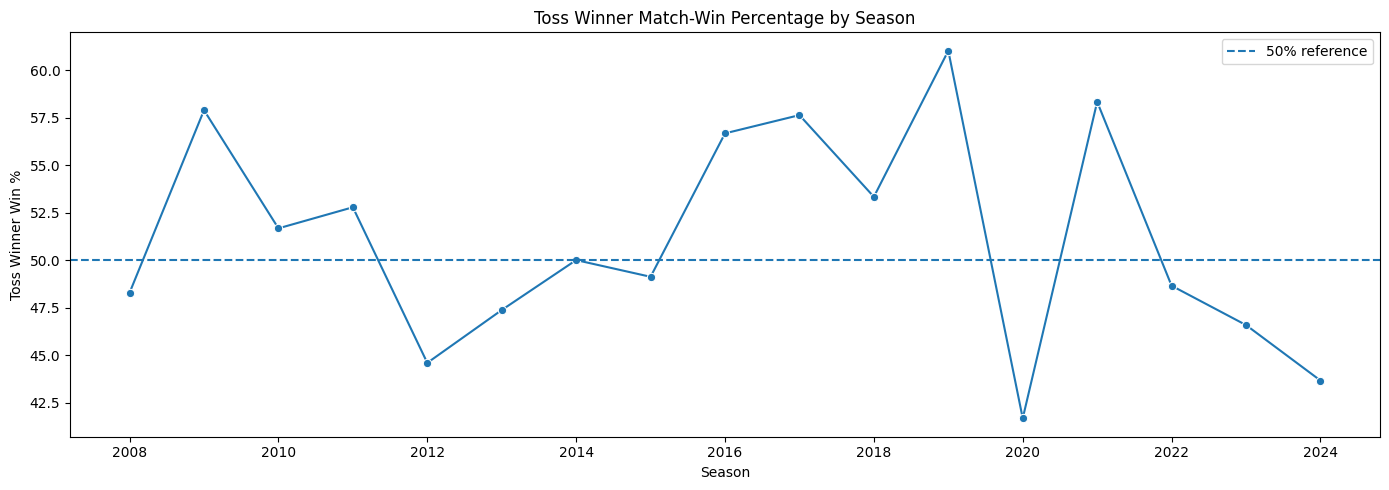

In [17]:
toss_by_season = (
    valid_toss_matches
    .groupby("season")
    .agg(
        matches=("id", "count"),
        toss_winner_wins=(
            "toss_winner_won_match",
            "sum"
        ),
        toss_winner_win_pct=(
            "toss_winner_won_match",
            "mean"
        )
    )
    .reset_index()
)

toss_by_season["toss_winner_win_pct"] = (
    toss_by_season["toss_winner_win_pct"] * 100
).round(2)

display(toss_by_season)
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=toss_by_season,
    x="season",
    y="toss_winner_win_pct",
    marker="o"
)

plt.axhline(
    50,
    linestyle="--",
    label="50% reference"
)

plt.title(
    "Toss Winner Match-Win Percentage by Season"
)

plt.xlabel("Season")
plt.ylabel("Toss Winner Win %")

plt.legend()
plt.tight_layout()
plt.show()

In [18]:
df["winner"] = df["winner"].fillna("No Winner")
print(df["winner"].isna().sum())

for col in df.columns:
    missing = df[col].isna().sum()

    if missing > 0:
        print(f"{col}: {missing}")



0
team1_home_city: 23
team2_home_city: 21
home_advantage: 25
team1_home_advantage: 23


In [19]:
boolean_columns = df.select_dtypes(
    include=["bool"]
).columns

for col in boolean_columns:
    df[col] = df[col].fillna(False)

numeric_columns = df.select_dtypes(
    include=["number"]
).columns

for col in numeric_columns:
    df[col] = df[col].fillna(0)

# Convert categorical columns to string first
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns

for col in categorical_columns:
    df[col] = df[col].astype("string")
    df[col] = df[col].fillna("Not Available")

In [20]:
#FINAL DATA QUALITY CHECK

print("Final Dataset Shape:", df.shape)

print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

print(
    "Duplicate Match IDs:",
    df["id"].duplicated().sum()
)

# Show any remaining missing values
remaining_missing = (
    df.isnull()
      .sum()
      .to_frame("Missing_Count")
      .query("Missing_Count > 0")
)

display(remaining_missing)

Final Dataset Shape: (1095, 33)
Total Missing Values: 0
Duplicate Rows: 0
Duplicate Match IDs: 0


,Missing_Count


## 📝 Question 2: Team Performance Clustering

### Task:
Perform **clustering analysis** to group teams based on their performance metrics:

1. Create team-level features:
   - Win percentage
   - Average victory margin (runs/wickets)
   - Toss win to match win ratio
   - Home vs away performance(optional based on assumption)
   - Venue familiarity effect: win% at a team’s top‑3 most played venues vs other venues.

2. Apply K-means clustering to identify team categories
3. Use elbow method to determine optimal clusters
4. Visualize clusters using PCA for dimensionality reduction(optional)

### Expected Output:
- Team clusters with labels (e.g., "Dominant Teams", "Inconsistent Performers")
- Cluster characteristics interpretation

```python
# Your code here
```

In [21]:
# PREPARE DATA FOR TEAM ANALYSIS

team_df = df[
    df["winner"].notna() &
    (df["winner"] != "No Winner")
].copy()

print("Matches available for team performance analysis:", len(team_df))

Matches available for team performance analysis: 1090


In [22]:
# CREATE TEAM-MATCH DATA

team1 = team_df[
    [
        "id",
        "season",
        "date",
        "venue",
        "city",
        "team1",
        "team2",
        "toss_winner",
        "toss_decision",
        "winner",
        "result",
        "result_margin"
    ]
].copy()

team1["team"] = team1["team1"]
team1["opponent"] = team1["team2"]

team1["won"] = (
    team1["winner"] == team1["team"]
).astype(int)

team1["toss_won"] = (
    team1["toss_winner"] == team1["team"]
).astype(int)

team1["batting_first"] = np.where(
    (team1["toss_won"] == 1) &
    (team1["toss_decision"] == "bat"),
    1,
    np.where(
        (team1["toss_won"] == 0) &
        (team1["toss_decision"] == "field"),
        0,
        np.nan
    )
)

team2 = team_df[
    [
        "id",
        "season",
        "date",
        "venue",
        "city",
        "team1",
        "team2",
        "toss_winner",
        "toss_decision",
        "winner",
        "result",
        "result_margin"
    ]
].copy()

team2["team"] = team2["team2"]
team2["opponent"] = team2["team1"]

team2["won"] = (
    team2["winner"] == team2["team"]
).astype(int)

team2["toss_won"] = (
    team2["toss_winner"] == team2["team"]
).astype(int)

team2["batting_first"] = np.where(
    (team2["toss_won"] == 1) &
    (team2["toss_decision"] == "bat"),
    1,
    np.where(
        (team2["toss_won"] == 0) &
        (team2["toss_decision"] == "field"),
        0,
        np.nan
    )
)

team_matches = pd.concat(
    [team1, team2],
    ignore_index=True
)

print("Team-match observations:", team_matches.shape)

display(team_matches.head())

Team-match observations: (2180, 17)


,id,season,date,venue,city,team1,team2,toss_winner,toss_decision,winner,result,result_margin,team,opponent,won,toss_won,batting_first
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,NaN
1,335983,2008,2008-04-19,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,Kings XI Punjab,Chennai Super Kings,0,0,NaN
2,335984,2008,2008-04-19,Feroz Shah Kotla,Delhi,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,Delhi Daredevils,Rajasthan Royals,1,0,NaN
3,335985,2008,2008-04-20,Wankhede Stadium,Mumbai,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,Mumbai Indians,Royal Challengers Bangalore,0,1,1.0
4,335986,2008,2008-04-20,Eden Gardens,Kolkata,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,Kolkata Knight Riders,Deccan Chargers,1,0,NaN


In [23]:
# WIN PERCENTAGE = matches won / matches played
team_performance = (
    team_matches
    .groupby("team")
    .agg(
        matches_played=("id", "count"),
        matches_won=("won", "sum")
    )
    .reset_index()
)

team_performance["win_percentage"] = (
    team_performance["matches_won"] /
    team_performance["matches_played"] *
    100
)

display(
    team_performance
    .sort_values("win_percentage", ascending=False)
)

,team,matches_played,matches_won,win_percentage
14,Rising Pune Supergiant,16,10,62.500000
5,Gujarat Titans,45,28,62.222222
0,Chennai Super Kings,237,138,58.227848
9,Lucknow Super Giants,43,24,55.813953
10,Mumbai Indians,261,144,55.172414
2,Delhi Capitals,91,48,52.747253
8,Kolkata Knight Riders,251,131,52.191235
13,Rajasthan Royals,219,112,51.141553
16,Royal Challengers Bangalore,237,116,48.945148
18,Sunrisers Hyderabad,182,88,48.351648


In [24]:
# VICTORY MARGIN

team_matches["win_margin_runs"] = np.where(
    (team_matches["won"] == 1) &
    (team_matches["result"].str.lower() == "runs"),
    team_matches["result_margin"],
    np.nan
)

team_matches["win_margin_wickets"] = np.where(
    (team_matches["won"] == 1) &
    (team_matches["result"].str.lower() == "wickets"),
    team_matches["result_margin"],
    np.nan
)

# Aggregate
margin_stats = (
    team_matches
    .groupby("team")
    .agg(
        avg_victory_margin_runs=(
            "win_margin_runs",
            "mean"
        ),
        avg_victory_margin_wickets=(
            "win_margin_wickets",
            "mean"
        )
    )
    .reset_index()
)

display(margin_stats)

,team,avg_victory_margin_runs,avg_victory_margin_wickets
0,Chennai Super Kings,34.943662,6.029851
1,Deccan Chargers,23.388889,6.545455
2,Delhi Capitals,24.000000,5.666667
3,Delhi Daredevils,27.000000,6.547619
4,Gujarat Lions,1.000000,5.416667
5,Gujarat Titans,34.181818,5.764706
6,Kings XI Punjab,25.850000,6.422222
7,Kochi Tuskers Kerala,11.500000,7.500000
8,Kolkata Knight Riders,33.592593,6.197368
9,Lucknow Super Giants,24.437500,5.375000


In [33]:
#TOSS WIN TO MATCH WIN RATIO

toss_stats = (
    team_matches
    .groupby("team")
    .agg(
        tosses_won=("toss_won", "sum"),
        matches_won=("won", "sum")
    )
    .reset_index()
)

# Number of matches where team won toss AND match
team_matches["toss_and_match_win"] = (
    (team_matches["toss_won"] == 1) &
    (team_matches["won"] == 1)
).astype(int)

toss_win_conversion = (
    team_matches
    .groupby("team")
    .agg(
        tosses_won=("toss_won", "sum"),
        toss_and_match_wins=("toss_and_match_win", "sum")
    )
    .reset_index()
)

toss_win_conversion["toss_to_match_win_ratio"] = np.where(
    toss_win_conversion["tosses_won"] > 0,
    toss_win_conversion["toss_and_match_wins"] /
    toss_win_conversion["tosses_won"],
    0
)

toss_win_conversion["toss_to_match_win_pct"] = (
    toss_win_conversion["toss_to_match_win_ratio"] * 100
)

display(
    toss_win_conversion.sort_values(
        "toss_to_match_win_pct",
        ascending=False
    )
)


,team,tosses_won,toss_and_match_wins,toss_to_match_win_ratio,toss_to_match_win_pct
14,Rising Pune Supergiant,6,5,0.833333,83.333333
4,Gujarat Lions,15,10,0.666667,66.666667
5,Gujarat Titans,22,14,0.636364,63.636364
0,Chennai Super Kings,121,75,0.619835,61.983471
8,Kolkata Knight Riders,122,68,0.557377,55.737705
10,Mumbai Indians,143,78,0.545455,54.545455
9,Lucknow Super Giants,19,10,0.526316,52.631579
2,Delhi Capitals,50,26,0.520000,52.000000
16,Royal Challengers Bangalore,112,57,0.508929,50.892857
13,Rajasthan Royals,118,60,0.508475,50.847458


In [34]:
# HOME CITY MAPPING

home_city_mapping = {
    "Mumbai Indians": "Mumbai",
    "Chennai Super Kings": "Chennai",
    "Royal Challengers Bengaluru": "Bengaluru",
    "Royal Challengers Bangalore": "Bangalore",
    "Kolkata Knight Riders": "Kolkata",
    "Delhi Capitals": "Delhi",
    "Delhi Daredevils": "Delhi",
    "Punjab Kings": "Mohali",
    "Kings XI Punjab": "Mohali",
    "Rajasthan Royals": "Jaipur",
    "Sunrisers Hyderabad": "Hyderabad",
    "Deccan Chargers": "Hyderabad",
    "Gujarat Titans": "Ahmedabad",
    "Lucknow Super Giants": "Lucknow",
    "Rising Pune Supergiant": "Pune",
    "Rising Pune Supergiants": "Pune",
    "Pune Warriors": "Pune"
}

team_matches["home_city"] = (
    team_matches["team"]
    .map(home_city_mapping)
)

team_matches["is_home"] = (
    team_matches["city"] ==
    team_matches["home_city"]
)

# Calculate Home and Away Performance
home_away = (
    team_matches
    .groupby(["team", "is_home"])
    .agg(
        matches=("id", "count"),
        wins=("won", "sum")
    )
    .reset_index()
)

home_away["win_percentage"] = (
    home_away["wins"] /
    home_away["matches"] * 100
)

display(home_away)

# Pivot
home_away_pivot = (
    home_away
    .pivot(
        index="team",
        columns="is_home",
        values="win_percentage"
    )
    .reset_index()
)

home_away_pivot.columns = [
    "team",
    "away_win_percentage",
    "home_win_percentage"
]

home_away_pivot["home_away_advantage"] = (
    home_away_pivot["home_win_percentage"] -
    home_away_pivot["away_win_percentage"]
)

display(
    home_away_pivot.sort_values(
        "home_away_advantage",
        ascending=False
    )
)

,team,is_home,matches,wins,win_percentage
0,Chennai Super Kings,False,166,88,53.012048
1,Chennai Super Kings,True,71,50,70.422535
2,Deccan Chargers,False,57,26,45.614035
3,Deccan Chargers,True,18,3,16.666667
4,Delhi Capitals,False,72,38,52.777778
5,Delhi Capitals,True,19,10,52.631579
6,Delhi Daredevils,False,97,40,41.237113
7,Delhi Daredevils,True,62,27,43.548387
8,Gujarat Titans,False,29,19,65.517241
9,Gujarat Titans,True,16,9,56.250000


,team,away_win_percentage,home_win_percentage,home_away_advantage
16,Sunrisers Hyderabad,41.600000,63.157895,21.557895
15,Royal Challengers Bengaluru,37.500000,57.142857,19.642857
11,Rajasthan Royals,46.296296,64.912281,18.615984
0,Chennai Super Kings,53.012048,70.422535,17.410487
12,Rising Pune Supergiant,55.555556,71.428571,15.873016
6,Kolkata Knight Riders,48.466258,59.090909,10.624651
8,Mumbai Indians,50.955414,61.538462,10.583048
3,Delhi Daredevils,41.237113,43.548387,2.311274
14,Royal Challengers Bangalore,48.876404,49.152542,0.276138
2,Delhi Capitals,52.777778,52.631579,-0.146199


In [35]:
# TOP 3 MOST PLAYED VENUES

venue_frequency = (
    team_matches
    .groupby(["team", "venue"])
    .size()
    .reset_index(name="matches")
)

venue_frequency["venue_rank"] = (
    venue_frequency
    .groupby("team")["matches"]
    .rank(
        method="first",
        ascending=False
    )
)

top3_venues = venue_frequency[
    venue_frequency["venue_rank"] <= 3
].copy()

display(
    top3_venues.sort_values(
        ["team", "venue_rank"]
    )
)

# Team's top 3 Venue
# Create a lookup set
top3_lookup = set(
    zip(
        top3_venues["team"],
        top3_venues["venue"]
    )
)

team_matches["top3_venue"] = [
    (team, venue) in top3_lookup
    for team, venue
    in zip(
        team_matches["team"],
        team_matches["venue"]
    )
]

# Calculate win percentage
venue_familiarity = (
    team_matches
    .groupby(["team", "top3_venue"])
    .agg(
        matches=("id", "count"),
        wins=("won", "sum")
    )
    .reset_index()
)

venue_familiarity["win_percentage"] = (
    venue_familiarity["wins"] /
    venue_familiarity["matches"] * 100
)

display(venue_familiarity)

# Pivot
venue_familiarity_pivot = (
    venue_familiarity
    .pivot(
        index="team",
        columns="top3_venue",
        values="win_percentage"
    )
    .reset_index()
)

venue_familiarity_pivot.columns = [
    "team",
    "other_venues_win_pct",
    "top3_venues_win_pct"
]

venue_familiarity_pivot["venue_familiarity_effect"] = (
    venue_familiarity_pivot["top3_venues_win_pct"] -
    venue_familiarity_pivot["other_venues_win_pct"]
)

display(
    venue_familiarity_pivot.sort_values(
        "venue_familiarity_effect",
        ascending=False
    )
)

,team,venue,matches,venue_rank
24,Chennai Super Kings,"MA Chidambaram Stadium, Chepauk",47,1.0
25,Chennai Super Kings,"MA Chidambaram Stadium, Chepauk, Chennai",15,2.0
12,Chennai Super Kings,Dubai International Cricket Stadium,14,3.0
66,Deccan Chargers,"Rajiv Gandhi International Stadium, Uppal",18,1.0
54,Deccan Chargers,Dr DY Patil Sports Academy,6,2.0
50,Deccan Chargers,Barabati Stadium,4,3.0
82,Delhi Capitals,Dubai International Cricket Stadium,13,1.0
75,Delhi Capitals,"Arun Jaitley Stadium, Delhi",12,2.0
101,Delhi Capitals,"Wankhede Stadium, Mumbai",9,3.0
111,Delhi Daredevils,Feroz Shah Kotla,55,1.0


,team,top3_venue,matches,wins,win_percentage
0,Chennai Super Kings,False,161,86,53.416149
1,Chennai Super Kings,True,76,52,68.421053
2,Deccan Chargers,False,47,21,44.680851
3,Deccan Chargers,True,28,8,28.571429
4,Delhi Capitals,False,57,33,57.894737
5,Delhi Capitals,True,34,15,44.117647
6,Delhi Daredevils,False,88,41,46.590909
7,Delhi Daredevils,True,71,26,36.619718
8,Gujarat Lions,False,13,7,53.846154
9,Gujarat Lions,True,17,6,35.294118


,team,other_venues_win_pct,top3_venues_win_pct,venue_familiarity_effect
14,Rising Pune Supergiant,40.000000,72.727273,32.727273
18,Sunrisers Hyderabad,40.800000,64.912281,24.112281
13,Rajasthan Royals,45.270270,63.380282,18.110011
0,Chennai Super Kings,53.416149,68.421053,15.004904
10,Mumbai Indians,50.306748,63.265306,12.958558
8,Kolkata Knight Riders,48.026316,58.585859,10.559543
17,Royal Challengers Bengaluru,40.000000,50.000000,10.000000
9,Lucknow Super Giants,52.380952,59.090909,6.709957
16,Royal Challengers Bangalore,46.710526,52.941176,6.230650
6,Kings XI Punjab,47.368421,43.859649,-3.508772


In [36]:
# FINAL TEAM FEATURE DATASET

team_features = team_performance.merge(
    margin_stats,
    on="team",
    how="left"
)

team_features = team_features.merge(
    toss_win_conversion[
        [
            "team",
            "tosses_won",
            "toss_to_match_win_pct"
        ]
    ],
    on="team",
    how="left"
)

team_features = team_features.merge(
    home_away_pivot[
        [
            "team",
            "home_win_percentage",
            "away_win_percentage",
            "home_away_advantage"
        ]
    ],
    on="team",
    how="left"
)

team_features = team_features.merge(
    venue_familiarity_pivot[
        [
            "team",
            "top3_venues_win_pct",
            "other_venues_win_pct",
            "venue_familiarity_effect"
        ]
    ],
    on="team",
    how="left"
)

display(team_features)

,team,matches_played,matches_won,win_percentage,avg_victory_margin_runs,avg_victory_margin_wickets,tosses_won,toss_to_match_win_pct,home_win_percentage,away_win_percentage,home_away_advantage,top3_venues_win_pct,other_venues_win_pct,venue_familiarity_effect
0,Chennai Super Kings,237,138,58.227848,34.943662,6.029851,121,61.983471,70.422535,53.012048,17.410487,68.421053,53.416149,15.004904
1,Deccan Chargers,75,29,38.666667,23.388889,6.545455,43,44.186047,16.666667,45.614035,-28.947368,28.571429,44.680851,-16.109422
2,Delhi Capitals,91,48,52.747253,24.000000,5.666667,50,52.000000,52.631579,52.777778,-0.146199,44.117647,57.894737,-13.777090
3,Delhi Daredevils,159,67,42.138365,27.000000,6.547619,79,44.303797,43.548387,41.237113,2.311274,36.619718,46.590909,-9.971191
4,Gujarat Lions,30,13,43.333333,1.000000,5.416667,15,66.666667,NaN,NaN,NaN,35.294118,53.846154,-18.552036
5,Gujarat Titans,45,28,62.222222,34.181818,5.764706,22,63.636364,56.250000,65.517241,-9.267241,56.000000,70.000000,-14.000000
6,Kings XI Punjab,190,88,46.315789,25.850000,6.422222,85,42.352941,NaN,46.315789,NaN,43.859649,47.368421,-3.508772
7,Kochi Tuskers Kerala,14,6,42.857143,11.500000,7.500000,8,50.000000,NaN,NaN,NaN,37.500000,50.000000,-12.500000
8,Kolkata Knight Riders,251,131,52.191235,33.592593,6.197368,122,55.737705,59.090909,48.466258,10.624651,58.585859,48.026316,10.559543
9,Lucknow Super Giants,43,24,55.813953,24.437500,5.375000,19,52.631579,53.846154,56.666667,-2.820513,59.090909,52.380952,6.709957


In [37]:
# CLEAN TEAM FEATURE DATASET

numeric_features = team_features.select_dtypes(
    include=np.number
).columns

team_features[numeric_features] = (
    team_features[numeric_features]
    .fillna(0)
)

print("Missing values:")
display(
    team_features.isnull()
    .sum()
    .to_frame("Missing")
)

Missing values:


,Missing
team,0
matches_played,0
matches_won,0
win_percentage,0
avg_victory_margin_runs,0
avg_victory_margin_wickets,0
tosses_won,0
toss_to_match_win_pct,0
home_win_percentage,0
away_win_percentage,0


In [38]:
# Select Features for K-Means
cluster_features = [
    "win_percentage",
    "avg_victory_margin_runs",
    "avg_victory_margin_wickets",
    "toss_to_match_win_pct",
    "home_away_advantage",
    "venue_familiarity_effect"
]

X_cluster = team_features[
    cluster_features
].copy()

display(X_cluster)

# Standardize Features
# ==========================================
# STANDARDIZATION
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_cluster
)

,win_percentage,avg_victory_margin_runs,avg_victory_margin_wickets,toss_to_match_win_pct,home_away_advantage,venue_familiarity_effect
0,58.227848,34.943662,6.029851,61.983471,17.410487,15.004904
1,38.666667,23.388889,6.545455,44.186047,-28.947368,-16.109422
2,52.747253,24.000000,5.666667,52.000000,-0.146199,-13.777090
3,42.138365,27.000000,6.547619,44.303797,2.311274,-9.971191
4,43.333333,1.000000,5.416667,66.666667,0.000000,-18.552036
5,62.222222,34.181818,5.764706,63.636364,-9.267241,-14.000000
6,46.315789,25.850000,6.422222,42.352941,0.000000,-3.508772
7,42.857143,11.500000,7.500000,50.000000,0.000000,-12.500000
8,52.191235,33.592593,6.197368,55.737705,10.624651,10.559543
9,55.813953,24.437500,5.375000,52.631579,-2.820513,6.709957


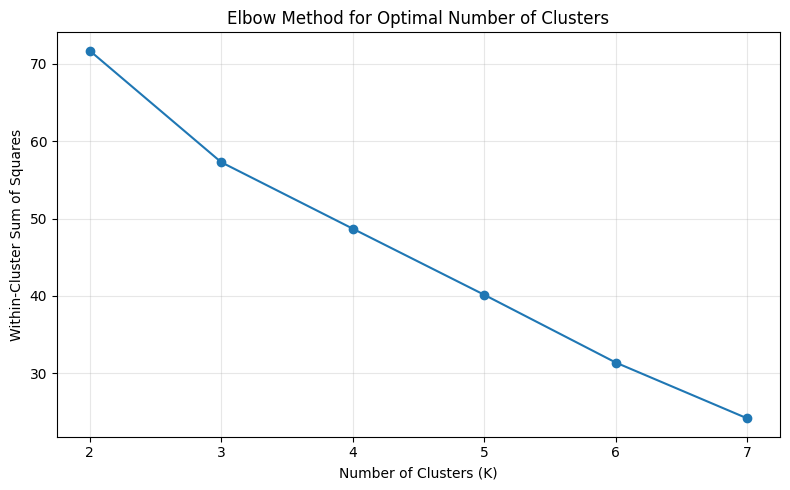

In [39]:
# ELBOW METHOD

inertia = []

K_range = range(2, 8)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(X_scaled)

    inertia.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares")

plt.xticks(K_range)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
# FINAL K-MEANS MODEL

optimal_k = 3   # Replace based on elbow + silhouette analysis

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

team_features["cluster"] = (
    kmeans.fit_predict(X_scaled)
)

display(
    team_features[
        ["team", "cluster"] +
        cluster_features
    ].sort_values("cluster")
)

,team,cluster,win_percentage,avg_victory_margin_runs,avg_victory_margin_wickets,toss_to_match_win_pct,home_away_advantage,venue_familiarity_effect
2,Delhi Capitals,0,52.747253,24.000000,5.666667,52.000000,-0.146199,-13.777090
4,Gujarat Lions,0,43.333333,1.000000,5.416667,66.666667,0.000000,-18.552036
5,Gujarat Titans,0,62.222222,34.181818,5.764706,63.636364,-9.267241,-14.000000
9,Lucknow Super Giants,0,55.813953,24.437500,5.375000,52.631579,-2.820513,6.709957
12,Punjab Kings,0,42.857143,20.909091,5.461538,37.500000,-25.098039,-14.035088
10,Mumbai Indians,1,55.172414,32.971831,6.197183,54.545455,10.583048,12.958558
8,Kolkata Knight Riders,1,52.191235,33.592593,6.197368,55.737705,10.624651,10.559543
0,Chennai Super Kings,1,58.227848,34.943662,6.029851,61.983471,17.410487,15.004904
14,Rising Pune Supergiant,1,62.500000,24.600000,6.200000,83.333333,15.873016,32.727273
13,Rajasthan Royals,1,51.141553,30.837209,5.835821,50.847458,18.615984,18.110011


In [41]:
# CLUSTER PROFILE

cluster_profile = (
    team_features
    .groupby("cluster")[cluster_features]
    .mean()
    .round(2)
)

display(cluster_profile)

,win_percentage,avg_victory_margin_runs,avg_victory_margin_wickets,toss_to_match_win_pct,home_away_advantage,venue_familiarity_effect
cluster,,,,,,
0,51.39,20.91,5.54,54.49,-7.47,-10.73
1,52.90,32.25,6.18,56.32,14.32,16.21
2,38.73,22.90,6.61,39.78,-13.20,-12.18


In [42]:
# Inspect
display(
    cluster_profile.sort_values(
        "win_percentage",
        ascending=False
    )
)
# ==========================================
# BUSINESS LABELS
# ==========================================

cluster_labels = {
    # Replace these after examining cluster_profile
    0: "Dominant Teams",
    1: "Inconsistent Performers",
    2: "Venue-Dependent Teams"
}

team_features["cluster_label"] = (
    team_features["cluster"]
    .map(cluster_labels)
)

display(
    team_features[
        [
            "team",
            "cluster",
            "cluster_label"
        ]
    ].sort_values("cluster")
)

,win_percentage,avg_victory_margin_runs,avg_victory_margin_wickets,toss_to_match_win_pct,home_away_advantage,venue_familiarity_effect
cluster,,,,,,
1,52.90,32.25,6.18,56.32,14.32,16.21
0,51.39,20.91,5.54,54.49,-7.47,-10.73
2,38.73,22.90,6.61,39.78,-13.20,-12.18


,team,cluster,cluster_label
2,Delhi Capitals,0,Dominant Teams
4,Gujarat Lions,0,Dominant Teams
5,Gujarat Titans,0,Dominant Teams
9,Lucknow Super Giants,0,Dominant Teams
12,Punjab Kings,0,Dominant Teams
10,Mumbai Indians,1,Inconsistent Performers
8,Kolkata Knight Riders,1,Inconsistent Performers
0,Chennai Super Kings,1,Inconsistent Performers
14,Rising Pune Supergiant,1,Inconsistent Performers
13,Rajasthan Royals,1,Inconsistent Performers


In [43]:
# PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)

team_features["PCA1"] = X_pca[:, 0]
team_features["PCA2"] = X_pca[:, 1]

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

Explained variance: [0.4806434  0.19607445]


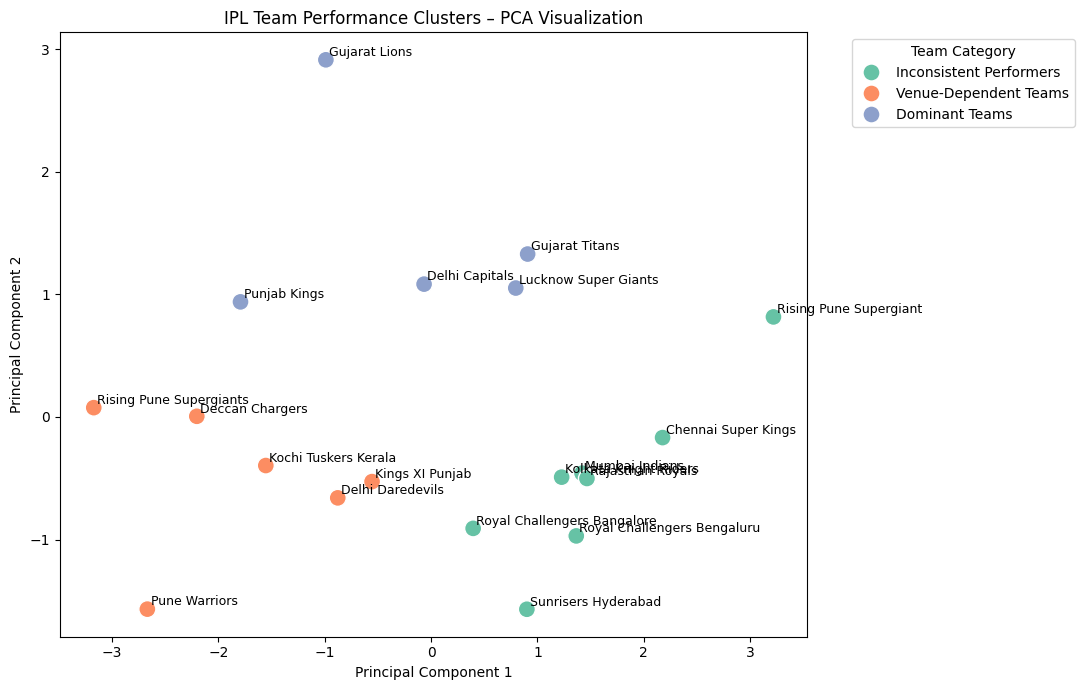

In [44]:
# Plot
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=team_features,
    x="PCA1",
    y="PCA2",
    hue="cluster_label",
    s=150,
    palette="Set2"
)

for _, row in team_features.iterrows():

    plt.text(
        row["PCA1"] + 0.03,
        row["PCA2"] + 0.03,
        row["team"],
        fontsize=9
    )

plt.title(
    "IPL Team Performance Clusters – PCA Visualization"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    title="Team Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

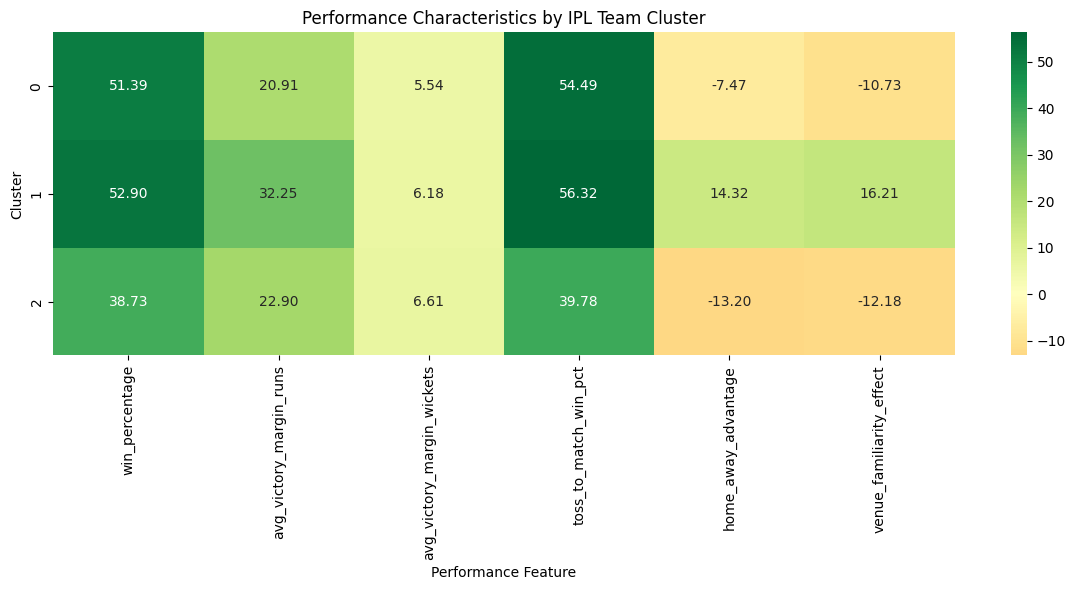

In [45]:
# Heatmap of Cluster Characteristics
plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0
)

plt.title(
    "Performance Characteristics by IPL Team Cluster"
)

plt.xlabel("Performance Feature")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

## 📝 Question 3: Match Outcome Prediction - Logistic Regression

### Task:
Build a **Logistic Regression** model to predict match winners:

1. Feature engineering:
   - One-hot encode categorical variables
   - Create interaction features (team × venue, team × toss)
   - Scale numerical features

2. Handle class imbalance using **SMOTE** if necessary

3. Apply **L1 and L2 regularization**:
   - Compare model performance
   - Identify most important features

4. Evaluate using:
   - ROC-AUC score
   - Precision-Recall curve
   - Feature importance plot

```python
# Your code here
```

In [46]:
# ==========================================
# QUESTION 3 - LOGISTIC REGRESSION
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    PolynomialFeatures
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings("ignore")

In [48]:
# ==========================================
# TARGET VARIABLE
# ==========================================

model_df = df[
    df["winner"].notna() &
    (df["winner"] != "No Winner")
].copy()

model_df["team1_won"] = (
    model_df["winner"] == model_df["team1"]
).astype(int)

print("Total matches:", len(model_df))

display(
    model_df["team1_won"]
    .value_counts()
    .to_frame("Matches")
)

class_distribution = (
    model_df["team1_won"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(
    class_distribution
    .to_frame("Percentage")
)

Total matches: 1090


,Matches
team1_won,
1,555
0,535


,Percentage
team1_won,
0,49.08
1,50.92


In [51]:
# ==========================================
# SORT CHRONOLOGICALLY
# ==========================================

model_df = model_df.sort_values(
    ["date", "id"]
).reset_index(drop=True)

# Create Historical Team Records
team_wins = {}
team_matches_played = {}

team1_prior_win_pct = []
team2_prior_win_pct = []

for _, row in model_df.iterrows():

    team1 = row["team1"]
    team2 = row["team2"]

    # Team 1 historical performance
    games1 = team_matches_played.get(team1, 0)
    wins1 = team_wins.get(team1, 0)

    if games1 > 0:
        win_pct1 = wins1 / games1
    else:
        win_pct1 = 0.50

    # Team 2 historical performance
    games2 = team_matches_played.get(team2, 0)
    wins2 = team_wins.get(team2, 0)

    if games2 > 0:
        win_pct2 = wins2 / games2
    else:
        win_pct2 = 0.50

    team1_prior_win_pct.append(win_pct1)
    team2_prior_win_pct.append(win_pct2)

    # Update history AFTER calculating features
    winner = row["winner"]

    for team in [team1, team2]:

        team_matches_played[team] = (
            team_matches_played.get(team, 0) + 1
        )

        if winner == team:
            team_wins[team] = (
                team_wins.get(team, 0) + 1
            )

model_df["team1_prior_win_pct"] = team1_prior_win_pct
model_df["team2_prior_win_pct"] = team2_prior_win_pct

model_df["team_strength_difference"] = (
    model_df["team1_prior_win_pct"] -
    model_df["team2_prior_win_pct"]
)

In [52]:
# Add Venue Experience
venue_features = [
    "venue_matches_team1_prior",
    "venue_matches_team2_prior"
]

display(
    model_df[
        venue_features
    ].head()
)

,venue_matches_team1_prior,venue_matches_team2_prior
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [56]:
# ==========================================
# TEAM × VENUE INTERACTIONS
# ==========================================

model_df["team1_venue"] = (
    model_df["team1"].astype(str)
    + "_"
    + model_df["venue"].astype(str)
)

model_df["team2_venue"] = (
    model_df["team2"].astype(str)
    + "_"
    + model_df["venue"].astype(str)
)

model_df["team1_won_toss"] = (
    model_df["toss_winner"] ==
    model_df["team1"]
).astype(int)

model_df["team2_won_toss"] = (
    model_df["toss_winner"] ==
    model_df["team2"]
).astype(int)

model_df["team1_toss_decision"] = (
    model_df["team1"].astype(str)
    + "_"
    + model_df["toss_decision"].astype(str)
)

In [58]:
# ==========================================
# MODEL FEATURES
# ==========================================

categorical_features = [
    "season",
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision",
    "team1_venue",
    "team2_venue",
    "team1_toss_decision"
]

numeric_features = [
    "team1_prior_win_pct",
    "team2_prior_win_pct",
    "team_strength_difference",
    "venue_matches_team1_prior",
    "venue_matches_team2_prior",
    "team1_won_toss"
]

features = (
    categorical_features +
    numeric_features
)

X = model_df[features].copy()
y = model_df["team1_won"].copy()

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 15
X shape: (1090, 15)
y shape: (1090,)


In [59]:
# ==========================================
# CHRONOLOGICAL TRAIN / TEST SPLIT
# ==========================================

test_season = model_df["season"].max()

train_mask = (
    model_df["season"] < test_season
)

test_mask = (
    model_df["season"] == test_season
)

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Training matches:", len(X_train))
print("Testing matches:", len(X_test))

print("\nTraining class distribution:")
display(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
display(y_test.value_counts(normalize=True))

Training matches: 1019
Testing matches: 71

Training class distribution:


,proportion
team1_won,
1,0.510304
0,0.489696



Testing class distribution:


,proportion
team1_won,
0,0.507042
1,0.492958


In [62]:
# ==========================================
# PREPROCESSING
# ==========================================

numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            drop=None
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features
    )
])

imbalance_ratio = (
    y_train.value_counts(normalize=True)
)

print(imbalance_ratio)

minority_pct = (
    y_train.value_counts(normalize=True).min()
)

print(
    f"Minority class: {minority_pct:.2%}"
)

team1_won
1    0.510304
0    0.489696
Name: proportion, dtype: float64
Minority class: 48.97%


In [63]:
# ==========================================
# L2 LOGISTIC REGRESSION
# ==========================================

l2_pipeline = ImbPipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "model",
        LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=2000,
            random_state=42
        )
    )
])

l2_pipeline.fit(
    X_train,
    y_train
)

l2_pred = l2_pipeline.predict(X_test)

l2_prob = l2_pipeline.predict_proba(
    X_test
)[:, 1]

In [69]:
# ==========================================
# L1 LOGISTIC REGRESSION
# ==========================================

l1_pipeline = ImbPipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "model",
        LogisticRegression(
            penalty="l1",
            C=1.0,
            solver="liblinear",
            max_iter=2000,
            random_state=42
        )
    )
])

l1_pipeline.fit(
    X_train,
    y_train
)

l1_pred = l1_pipeline.predict(X_test)

l1_prob = l1_pipeline.predict_proba(
    X_test
)[:, 1]

In [70]:
# ==========================================
# MODEL EVALUATION
# ==========================================

def evaluate_model(
    model_name,
    y_true,
    predictions,
    probabilities
):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            probabilities
        ),
        "Average_Precision": average_precision_score(
            y_true,
            probabilities
        )
    }



In [72]:
 results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression - L1",
        y_test,
        l1_pred,
        l1_prob
    ),

    evaluate_model(
        "Logistic Regression - L2",
        y_test,
        l2_pred,
        l2_prob
    )
])

display(
    results.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision
0,Logistic Regression - L1,0.4648,0.4571,0.4571,0.4571,0.4865,0.4828
1,Logistic Regression - L2,0.4648,0.4595,0.4857,0.4722,0.4722,0.4526


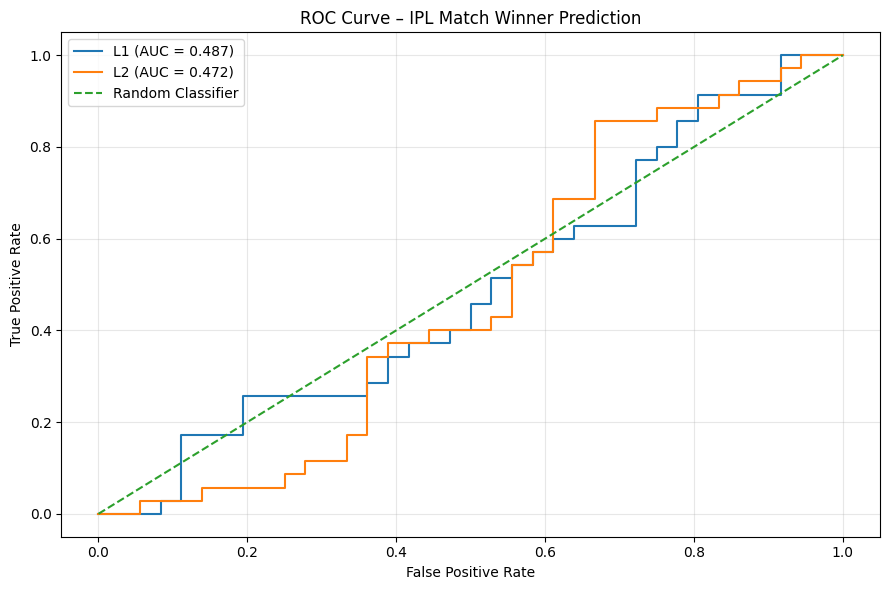

In [73]:
# ==========================================
# ROC CURVE
# ==========================================

fpr_l1, tpr_l1, _ = roc_curve(
    y_test,
    l1_prob
)

fpr_l2, tpr_l2, _ = roc_curve(
    y_test,
    l2_prob
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_l1,
    tpr_l1,
    label=f"L1 (AUC = {roc_auc_score(y_test, l1_prob):.3f})"
)

plt.plot(
    fpr_l2,
    tpr_l2,
    label=f"L2 (AUC = {roc_auc_score(y_test, l2_prob):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve – IPL Match Winner Prediction"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

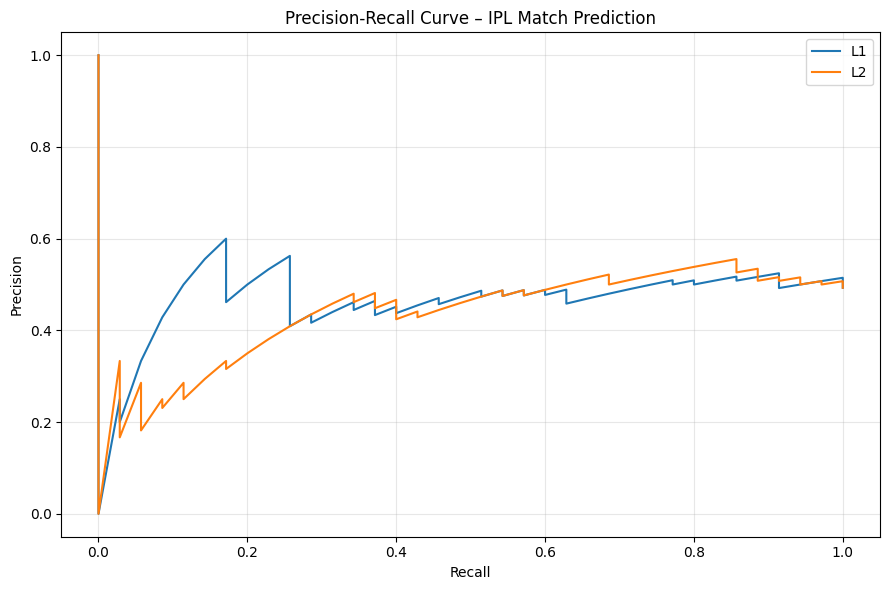

In [74]:
# ==========================================
# PRECISION-RECALL CURVE
# ==========================================

precision_l1, recall_l1, _ = (
    precision_recall_curve(
        y_test,
        l1_prob
    )
)

precision_l2, recall_l2, _ = (
    precision_recall_curve(
        y_test,
        l2_prob
    )
)

plt.figure(figsize=(9, 6))

plt.plot(
    recall_l1,
    precision_l1,
    label="L1"
)

plt.plot(
    recall_l2,
    precision_l2,
    label="L2"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve – IPL Match Prediction"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [75]:
# ==========================================
# FEATURE NAMES
# ==========================================

fitted_preprocessor = (
    l1_pipeline
    .named_steps["preprocessor"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(feature_names)
)

Number of transformed features: 822


In [77]:
l1_coefficients = (
    l1_pipeline
    .named_steps["model"]
    .coef_[0]
)

l1_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": l1_coefficients
})

l1_importance["absolute_coefficient"] = (
    l1_importance["coefficient"]
    .abs()
)

l1_importance = (
    l1_importance
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
)

display(
    l1_importance.head(25)
)

,feature,coefficient,absolute_coefficient
31,categorical__team1_Lucknow Super Giants,1.369538,1.369538
810,categorical__team1_toss_decision_Pune Warriors...,-1.299168,1.299168
45,categorical__team2_Gujarat Titans,-1.244240,1.244240
174,categorical__team1_venue_Deccan Chargers_Rajiv...,-1.165339,1.165339
290,categorical__team1_venue_Mumbai Indians_Mahara...,-1.152680,1.152680
534,categorical__team2_venue_Kings XI Punjab_Punja...,-1.048022,1.048022
136,categorical__team1_venue_Chennai Super Kings_B...,-1.047216,1.047216
741,categorical__team2_venue_Royal Challengers Ban...,0.940830,0.940830
768,categorical__team2_venue_Sunrisers Hyderabad_M...,0.916799,0.916799
811,categorical__team1_toss_decision_Punjab Kings_bat,-0.889320,0.889320


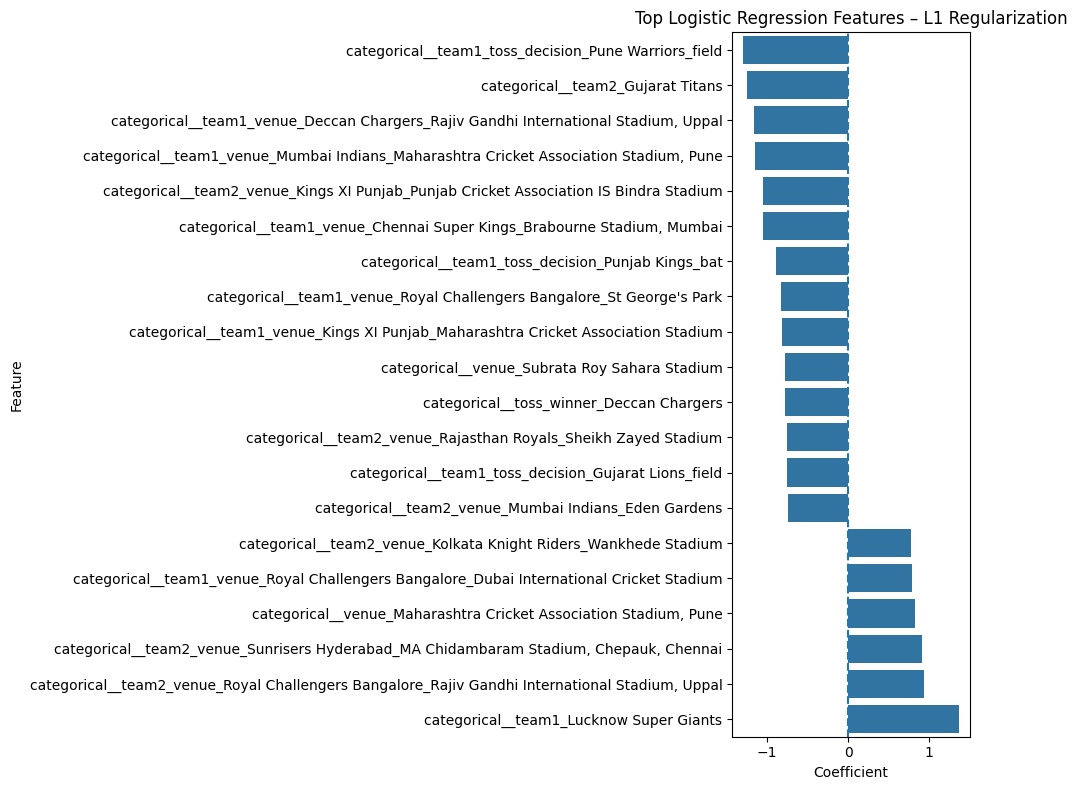

In [78]:
# Visualize L1 Feature Importance
top_l1 = (
    l1_importance
    .head(20)
    .sort_values("coefficient")
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_l1,
    x="coefficient",
    y="feature"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Top Logistic Regression Features – L1 Regularization"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [79]:
# ==========================================
# L1 + SMOTE
# ==========================================

l1_smote_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),

    ("smote", SMOTE(
        random_state=42
    )),

    ("model", LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

l1_smote_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['team1_prior_win_pct',
                                                   'team2_prior_win_pct',
                                                   'team_strength_difference',
                                                   'venue_matches_team1_prior',
                                                   'venue_matches_team2_prior',
                                                   'team1_won_toss']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['season', 'team1', 'team2',
                                                   'venue', 'toss_winner',
                                                   'toss_decision',
                                                   'team1_venue', 'team2_venue',
                                                   'team1_toss_decision'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(max_iter=2000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

## 📝 Question 4: Performance Trend Analysis

### Task:
Use **Linear Regression** to analyze performance trends:

1. Track team performance over seasons:
   - Create yearly win percentage for each team
   - Fit linear regression to identify improving/declining teams

2. Predict next season performance

3. Identify factors affecting performance trends: (For example)
   - Toss luck: per‑season difference between toss win% and match win%.
   - Venue familiarity exposure: share of matches at team’s top‑3 venues.
   - Opponent strength index: seasonal average win% of opponents.

### Visualization:
- Time series plot with regression lines for top 5 teams

```python
# Your code here
```

## 📝 Question 5: Player of Match Prediction - KNN

### Task:
Use **K-Nearest Neighbors (KNN)** to predict potential 'Player of Match':

1. Build match‑context features:

Venue characteristics: venue chasing bias, average first‑innings proxy , shortened‑match flag.

Team strengths: recent win% (rolling window or per‑season).

Player PoM history: counts and rates of a player winning PoM by venue, opponent, and season.

Find similar historical matches (KNN on the context features).

Predict top‑k candidate PoM names (rank by neighbor votes or PoM prior × similarity).

Tune k via cross‑validation.

```python
# Your code here
```

## 📝 Question 6: Toss Decision Strategy - Decision Tree

### Task:
Build a **Decision Tree** to recommend toss decisions:

1. Create a model to predict optimal toss decision (bat/field) based on:
   - Venue history
   - Weather conditions (create synthetic if not available)
   - Team strengths
   - Match importance

2. Visualize the decision tree (max_depth=5)

3. Extract decision rules in plain English

4. Calculate feature importance

### Business Application:
"Provide captains with data-driven toss decision recommendations"

```python
# Your code here
```

## 📝 Question 7: Advanced Match Prediction - Ensemble Methods

### Task:
Compare **Bagging** and **Boosting** for match outcome prediction:

1. Implement Random Forest (Bagging):
   - Use all available features
   - Tune hyperparameters
   - Feature importance analysis

2. Implement XGBoost/AdaBoost (Boosting):
   - Compare with Random Forest
   - Analyze prediction confidence

3. Create an ensemble combining both approaches

4. Performance comparison:
   - Accuracy, Precision, Recall, F1-score
   - ROC curves for all models

```python
# Your code here
```

# FEATURES mentioned in questions are high level example. You can create more features to make your model robust

## 📤 Submission Guidelines

1. Submit a single Jupyter notebook with all solutions
2. Include markdown cells explaining your approach
3. Ensure all code is reproducible
4. Add a summary section with key findings
5. List any assumptions made

## 💡 Tips
- Focus on practical insights over complex models
- Validate all findings with appropriate metrics
- Consider real-world IPL scenarios in your analysis
- Document any data quality issues encountered

---

<div style="background-color: #f0f8ff; padding: 15px; border-radius: 10px; text-align: center;">
<h3>🏆 Good Luck!</h3>
<p>May the best Data Scientist win!</p>
</div>